# Probability and Convergence: A Simulation Approach

Welcome to this interactive notebook! This project explores foundational statistical concepts, specifically the **Law of Large Numbers** and the **Central Limit Theorem (CLT)**.

The core goal of this notebook is to solve probability problems using two distinct methods and compare their results:
1. **The Empirical Approach:** Using Python to simulate massive amounts of random events.
2. **The Analytical Approach:** Using pure mathematics and probability formulas to find the exact theoretical expectation.

By doing this, we will see firsthand how simulated data beautifully converges to theoretical mathematics.

---
## Part 1: The Coin Flip Experiment

Imagine flipping a fair coin 10,000 times. Intuitively, we expect the coin to land on "heads" about 5,000 times. But what if we ask a more specific statistical question: **What is the probability of getting more than 5,200 heads?**

To answer this, we will approach the problem empirically. We will simulate this massive 10,000-flip experiment **100,000 times** and look at the distribution of the results. 

> **A Note on Performance:** > Running a standard `for-loop` 100,000 times in Python to simulate individual coin flips is computationally expensive and slow. Below, I have included the intuitive loop approach to show the logic, but the actual execution uses **vectorized binomial distribution**. This optimization reduces execution time from minutes to milliseconds.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

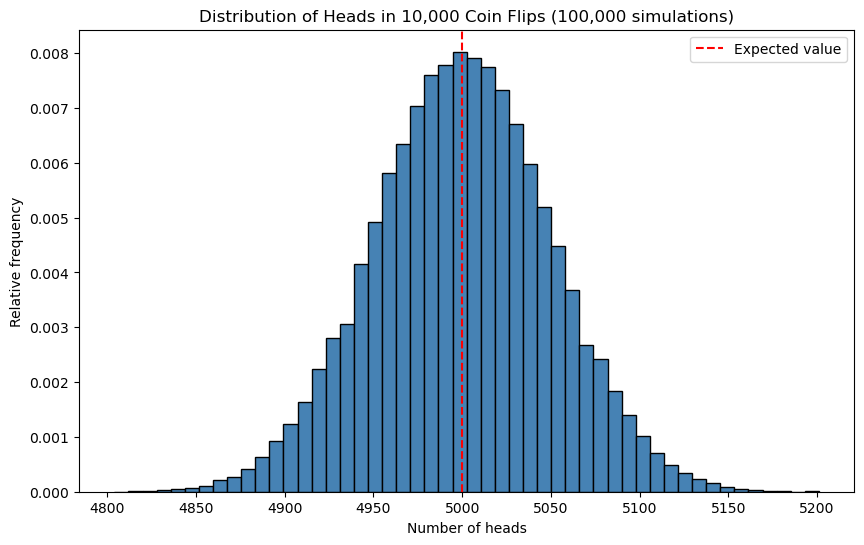

In [13]:
# Set the parameters for the simulation
n_flips = 10000    # Number of coin flips in a single experiment
n_sim = 100000     # Number of simulations to run
target = 5050      # Target number of heads we are investigating

# Slow approach using a for-loop 
# results = []
# for i in range(n_sim):
#     flips = np.random.randint(0, 2, n_flips)
#     head = np.sum(flips)
#     results.append(head)    

# Optimized vectorized approach using binomial distribution
results = np.random.binomial(n=n_flips, p=0.5, size=n_sim)

# Visualization of the results
plt.figure(figsize=(10, 6))
plt.hist(results, bins=50, edgecolor='black', color='steelblue', density=True)
plt.axvline(x=n_flips/2, color='red', linestyle='--', label='Expected value')
plt.title(f'Distribution of Heads in {n_flips:,} Coin Flips ({n_sim:,} simulations)')
plt.xlabel('Number of heads')
plt.ylabel('Relative frequency')
plt.legend()
plt.show()

### Calculating the Empirical Probability

Now that our massive simulation is complete, we can finally answer our initial question. 

To find the empirical probability, we simply calculate the proportion of our 100,000 simulations where the number of heads strictly exceeded our target of 5,200. Let's see the result:

In [14]:
probability_empirical = np.mean(results > target)
print(f"Empirical probability (> {target} heads): {probability_empirical:.6f}")

Empirical probability (> 5050 heads): 0.155970


---
## Part 2: The Analytical Approach (Central Limit Theorem)

In Part 1, our simulation gave us an **empirical probability** based on generated data. But how accurate is that simulation? Let's find out by calculating the exact mathematical truth.

According to the **Central Limit Theorem (CLT)**, as the number of independent trials (coin flips) becomes large, the binomial distribution can be approximated by a normal distribution. 

We can calculate the exact theoretical probability by finding the **Z-score**. To do this, we need the expected value (mean, $\mu$) and the standard deviation ($\sigma$) of our distribution:
* **Mean ($\mu$):** $n \cdot p$
* **Standard Deviation ($\sigma$):** $\sqrt{n \cdot p \cdot (1 - p)}$

*Note: Because we are approximating a discrete distribution (coin flips) with a continuous normal distribution, we apply a continuity correction of +0.5 to our target value for maximum accuracy.*

In [15]:
p = 0.5
mu = n_flips * p
sigma = np.sqrt(n_flips * p * (1 - p))

# Calculate Z-score with continuity correction (+0.5 for "greater than")
z = (target+0.5 - mu) / sigma
print(f"Calculated Z-score: {z:.4f}")

# Calculate the theoretical probability using the Cumulative Distribution Function (CDF)
probability_analytical = 1 - stats.norm.cdf(z)
print(f"Analytical probability (CLT): {probability_analytical:.6f}")

Calculated Z-score: 1.0100
Analytical probability (CLT): 0.156248


---
## Part 3: The Law of Large Numbers and Convergence

You might notice that our empirical probability and analytical probability are extremely close, but rarely *exactly* identical. This is the nature of randomness. 

However, the **Law of Large Numbers (LLN)** guarantees that as the number of trials (simulations) increases, the empirical average will converge to the expected theoretical value. 

Instead of just stating this, let's visualize the convergence. We can track the cumulative empirical probability as the simulation progresses from trial 1 to 100,000 and see how it settles on our analytical CLT line.

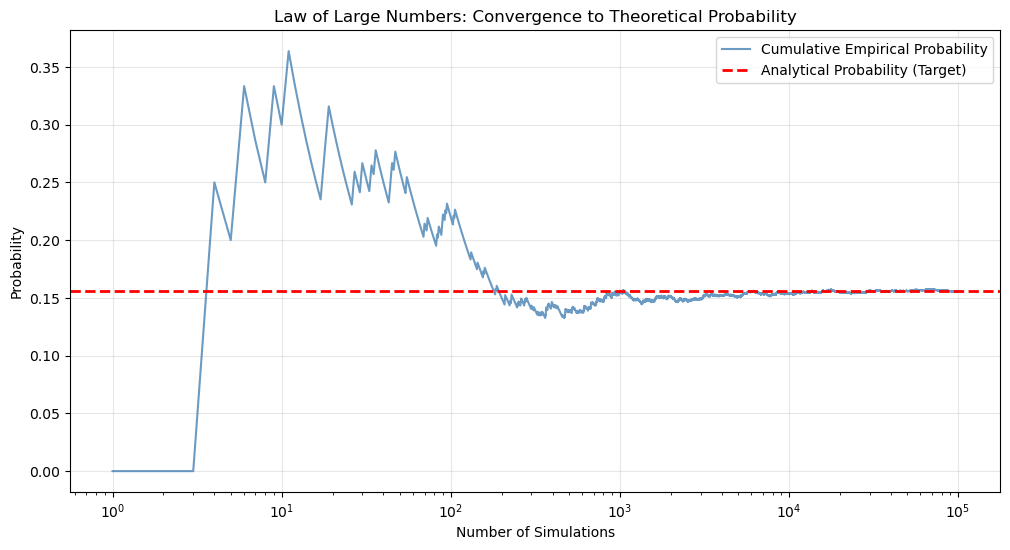

In [16]:
# Calculate cumulative empirical probability over time
# We count how many times we hit our target cumulatively, divided by the number of trials at that point
cumulative_successes = np.cumsum(results > target)
trials = np.arange(1, n_sim + 1)
cumulative_prob = cumulative_successes / trials

# Plotting the convergence
plt.figure(figsize=(12, 6))

# Plot the empirical probability as it evolves
plt.plot(trials, cumulative_prob, color='steelblue', alpha=0.8, label='Cumulative Empirical Probability')

# Plot the exact analytical probability as a straight target line
plt.axhline(y=probability_analytical, color='red', linestyle='--', linewidth=2, label='Analytical Probability (Target)')

plt.title('Law of Large Numbers: Convergence to Theoretical Probability')
plt.xlabel('Number of Simulations')
plt.ylabel('Probability')
plt.xscale('log') # Logarithmic scale helps see the wild variations at the beginning
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

---
## Part 4: The Monty Hall Paradox

Let's shift gears to one of the most famous and counter-intuitive problems in probability theory: **The Monty Hall Problem**.

**The Setup:**
Imagine you are on a game show. You are given the choice of three doors: 
* Behind one door is a car (the prize).
* Behind the other two doors are goats.

You pick a door (let's say Door 1). The host, who knows what is behind all the doors, opens another door (let's say Door 3), which has a goat. He then says to you: *"Do you want to switch your choice to Door 2?"*

**The Question:** Is it to your advantage to switch your choice?

Intuitively, most people believe that with two doors left, the odds are exactly 50/50. Let's write a highly optimized Python simulation to test this theory by playing the game 100,000 times!

In [37]:
def monty_hall(switch, n_sim=10000):
    wins=0
    for i in range(n_sim):
        choice=np.random.randint(0,3)
        prize=np.random.randint(0,3)
        if switch:
            wins+=(choice!=prize)
        else:
            wins+=(choice==prize)
    return wins/n_sim

print(f"Win rate (stay): {monty_hall(switch=False):.3f}")
print(f"Win rate (switch): {monty_hall(switch=True):.3f}")    

Win rate (stay): 0.329
Win rate (switch): 0.673


### Why Does Switching Win ~66.6% of the Time?

The simulation empirically proves that switching is the superior strategy. Here is the mathematical logic behind it:

1. When you make your first choice, you have a **1/3** chance of picking the car and a **2/3** chance of picking a goat.
2. If you choose to **stay**, you are betting entirely on your first choice. Your win rate remains exactly **1/3 (~33.3%)**.
3. If you chose a goat initially (which happens **2/3** of the time), the host *must* open the other door with a goat. That means the remaining closed door MUST hide the car. 
4. Therefore, if you adopt the **switching strategy**, you will win every single time your first choice was a goat. Since your first choice is a goat 2/3 of the time, the switching strategy gives you a **2/3 (~66.6%)** win rate.

Once again, computational simulation beautifully validates theoretical probability!